This notebook shows a simple example how to **optimize** **vector fields**.

There are two _**particles**_ placed in a **2D** plane with **vortex vector fields** around them.
Their **positions** are **optimized** so that the total field, **projected** onto a
**horizontal monitor line**, has the **largest possible peak value**.

Around each particle there is a smooth **donut-shaped vortex vector field**:
the **vectors** are **tangent** to concentric circles around the particle, and their
**magnitude** is greatest on a ring of a chosen **radius** with a Gaussian falloff of
width **sigma** on either side of that ring. Away from the ring — both toward
the particle center and far away — the field decays to zero. This gives a
well-defined smooth field with no singularities.

Each vortex has a **handedness**: $+1$ means the vectors point counter-clockwise
(CCW) around the particle, $-1$ means clockwise (CW).

The **total field** is the sum of the two individual vortex fields. Where the
donuts overlap, contributions add — sometimes constructively, sometimes
destructively, depending on handedness and geometry.

An imaginary horizontal **_monitor line_** at $y=0$ runs across a segment of the
domain. Along that line we measure the **$x$-component** of the total field. We
want to arrange the two **particles** so that the **peak value** of that projection
is as **large as possible**.

Concretely, the objective is:
$$\min_{x_1,\,y_1,\,x_2,\,y_2}\; \left[- \max_{x \text{ on line}} v_x(x, 0)\right].$$

For particles with **opposite handedness** ($h_1 = +1$, $h_2 = -1$):

* each should sit at distance **radius** from the line, on opposite sides ($y_1 = +r$, $y_2 = -r$);
* they should be **vertically stacked** ($x_1 = x_2$) so both ring peaks meet on
  the line at the same $x$;
* under this configuration each contributes value $1$ at the same point on the
  line, adding to $2$.

The **horizontal position** of the pair is **arbitrary**. The **objective** is
**translationally invariant along the line**, so the optimizer settles wherever
the initial condition drops it.

For **same handedness** ($h_1 = h_2$) the contributions on the line *cancel*
when the particles are stacked, so the **optimum flips**: the particles push apart
until their donuts no longer touch on the monitor line. The peak then saturates
at $1$ (a single particle acting alone) and there's no further pressure to
separate.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/peterropac/Aegolius/blob/main/examples/autodiff/vector_field_optimization.ipynb)

# IMPORTS


In [ ]:
#@title Setup
import importlib.util
if importlib.util.find_spec('google.colab') is not None:
    %pip install -q spomso optax


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from time import process_time

from jax import value_and_grad, config
import jax.numpy as jnp
import optax

from spomso.cores.helper_functions import generate_grid, smarter_reshape
from spomso.jax_cores.vector_functions_jax import vortex_vector_field_cylindrical
from spomso.jax_cores.sdf_2D_jax import sdf_circle
from spomso.jax_cores.post_processing_jax import gaussian_boundary_jax

config.update("jax_enable_x64", True)
config.update("jax_debug_nans", True)

# PARAMETERS

`radius` and `sigma` control the shape of the vortex donut independently:

* `radius` is the radius of the ring where each vortex peaks.
* `sigma` is the width of the Gaussian envelope on either side of that ring.

`handedness_1` and `handedness_2` set the rotation direction of each particle.

In [2]:
# size of the 2D domain (used for plotting only)
co_size = 8, 8
co_resolution = 400, 400

# radius of the ring where the vortex peaks
radius = 1.0
# Gaussian envelope width on either side of the ring
sigma = 2.0

# particle handedness. +1 = CCW, -1 = CW.
handedness_1 = 1
handedness_2 = -1

# monitor line: horizontal at y = line_y, spanning x in (-line_extent/2, +line_extent/2)
line_y = 0.0
line_extent = 6.0
n_line_samples = 500

# random seed for the initial particle positions
seed = 24072026

# FIELD -> plot |v(r)| behind the quiver; PROJECTION -> plot v_x(r) behind the quiver
show = "FIELD"
show_midplane = True
show_projection = True

# COORDINATE SYSTEM



Point cloud of coordinates is created with the **generate_grid** function, which takes the size of the coordinate system and the number of points in each direction (**co_resolution**).

In [3]:
coor, co_res_new = generate_grid(co_size, co_resolution)

Define the points along the **monitor line**:

In [4]:
line_x = jnp.linspace(-line_extent/2, line_extent/2, n_line_samples)
line_coor = jnp.stack([line_x, jnp.full_like(line_x, line_y), jnp.zeros_like(line_x)])

# CREATE THE VECTOR FIELD



Each donut vortex is composed from three **_SPOMSO_** built-ins:

1. `vortex_vector_field_cylindrical(p)` gives a **unit tangent field** around the $z$-axis.
2. `sdf_circle(p, radius)` returns the **signed distance** to a **ring** of the given **radius**
   centered at the origin.
3. `gaussian_boundary_jax(sdf, 1, sigma)` converts that **signed distance** into a
   **Gaussian envelope** that peaks on the ring itself.

Multiplying the **unit tangent field** by the **envelope** gives a **smooth donut-shaped
tangential flow**. `handedness` selects rotation direction. The **particle position**
enters via `p = coor_ - (x0, y0, 0)`, which recenters everything on the particle.

In [5]:
def vortex(coor_, x0, y0, handedness):
    p = jnp.subtract(coor_.T, jnp.asarray([x0, y0, 0])).T
    vf = vortex_vector_field_cylindrical(p)
    sdf = sdf_circle(p, radius)
    f = gaussian_boundary_jax(sdf, 1, sigma)
    out = vf * f * handedness
    return out[:2]

Before combining two, let's visualise one vortex at the origin. Vectors should
be tangential, peaking on the ring at `radius`, and decaying to zero at the
center and far from the particle.

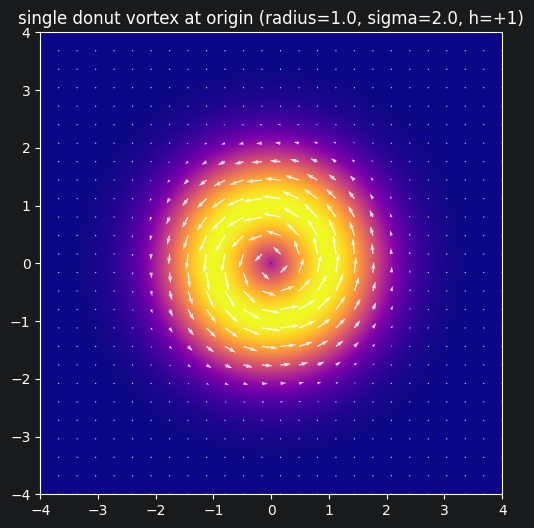

In [6]:
single = vortex(coor, 0.0, 0.0, +1.0)
single_mag = jnp.linalg.norm(single, axis=0)
res2d = (co_res_new[0], co_res_new[1])
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(np.asarray(smarter_reshape(single_mag, co_resolution)).T,
          cmap="plasma", origin="lower",
          extent=(-co_size[0]/2, co_size[0]/2, -co_size[1]/2, co_size[1]/2))
step = co_resolution[0] // 25
X = coor[0].reshape(res2d)[::step, ::step]
Y = coor[1].reshape(res2d)[::step, ::step]
U = np.asarray(single[0]).reshape(res2d)[::step, ::step]
V = np.asarray(single[1]).reshape(res2d)[::step, ::step]
ax.quiver(X, Y, U, V, color="white", scale_units="xy", scale=3.0, width=0.003, alpha=0.85)
ax.set_aspect("equal")
ax.set_title(f"single donut vortex at origin (radius={radius}, sigma={sigma}, h=+1)")
plt.show()

# PRECOMPUTE


Compute the **total field**:

In [7]:
def total_field(coor_, params):
    x1, y1, x2, y2 = params
    return vortex(coor_, x1, y1, handedness_1) + vortex(coor_, x2, y2, handedness_2)

Define the **worker** for the **optax optimizer**. This function takes the **optimized parameters** as the *input* and *returns* the **value** of the **cost function**:

In [8]:
def worker(p):
    field_on_line = total_field(line_coor, p)
    projection = field_on_line[0]
    return -jnp.max(projection)

## Initial condition

Positions are drawn randomly, but with one small assist: one particle above the
line and one below. Without this, an optimizer starting with both particles on
the same side often gets stuck in a local minimum where they never cross the
line. The correct symmetric configuration is still non-trivially far from a
random starting point.

In [9]:
rng = np.random.default_rng(seed)
x1_init = float(rng.uniform(-co_size[0]/2, co_size[0]/2))
x2_init = float(rng.uniform(-co_size[0]/2, co_size[0]/2))
y1_init = float(rng.uniform(0.3, co_size[1]/2))
y2_init = float(-rng.uniform(0.3, co_size[1]/2))
init_params = jnp.asarray([x1_init, y1_init, x2_init, y2_init])
print(f"Initial parameters: p1 = ({x1_init:.3f}, {y1_init:.3f}), "
      f"p2 = ({x2_init:.3f}, {y2_init:.3f})")

Initial parameters: p1 = (-2.027, 2.450), p2 = (-0.513, -3.644)


# OPITIMIZATION PARAMETERS


In [10]:
max_iterations = 1000
relative_cost_difference = 1e-10
stop_cost_value = -1e12
start_learning_rate = 0.1

# FIND THE SOLUTION

**Initialize parameters** of the **model** and **optimizer**:

In [11]:
start_time = process_time()

params = init_params
optimizer = optax.adam(start_learning_rate)
opt_state = optimizer.init(params)

trajectory = [np.asarray(params)]
cost_history = []

**Optimization/update loop:**

In [12]:
prev_value = 1e16
best_value, best_params = 1e16, params
for i in range(max_iterations):
    value, grads = value_and_grad(worker)(params)
    updates, opt_state = optimizer.update(grads, opt_state)

    cost_history.append(float(value))

    if value < stop_cost_value:
        break

    rtol = jnp.abs(value / prev_value - 1)
    if rtol < relative_cost_difference:
        break
    else:
        prev_value = value

    params = optax.apply_updates(params, updates)
    if value < best_value:
        best_value, best_params = value, params

    trajectory.append(np.asarray(params))

## Final results:

In [13]:
value, _ = value_and_grad(worker)(params)
if value > best_value:
    value, params = best_value, best_params

end_time = process_time()
print(f"Optimization completed in {end_time - start_time:.2f} s over {i+1} iterations")
print(f"Final objective: {value:.4f}")
print(f"Final parameters: p1 = ({params[0]:.3f}, {params[1]:.3f}), "
      f"p2 = ({params[2]:.3f}, {params[3]:.3f})")

x1_sol, y1_sol, x2_sol, y2_sol = tuple(np.asarray(params))
trajectory = np.asarray(trajectory)

Optimization completed in 13.91 s over 207 iterations
Final objective: -2.0000
Final parameters: p1 = (-1.437, 1.000), p2 = (-1.437, -1.000)


For opposite handedness ($h_1 = +1$, $h_2 = -1$) the optimizer should find:

* $|y_1| \approx |y_2| \approx r$ (each particle at the ring radius from the line);
* opposite signs on $y_1$ and $y_2$;
* similar $x_1 \approx x_2$ (though this direction is nearly flat — the objective
  only weakly prefers a specific horizontal position, so the exact converged
  values depend on the starting point and step-size).

The final peak of the projection on the line should be close to $2$.

If you flipped one handedness so both are $+1$, you would instead see the particles
push apart until their donuts no longer overlap on the line, with the peak
saturating at $1$.

# EVALUATE THE SOLUTION


In [14]:
field_flat = total_field(coor, params)

if show == "PROJECTION":
    displayed = field_flat[0]
    displayed_label = "field projection onto monitor line direction"
else:
    displayed = jnp.linalg.norm(field_flat, axis=0)
    displayed_label = "field magnitude"

displayed_grid = smarter_reshape(displayed, co_resolution)
field = np.asarray(displayed_grid)

# PLOT

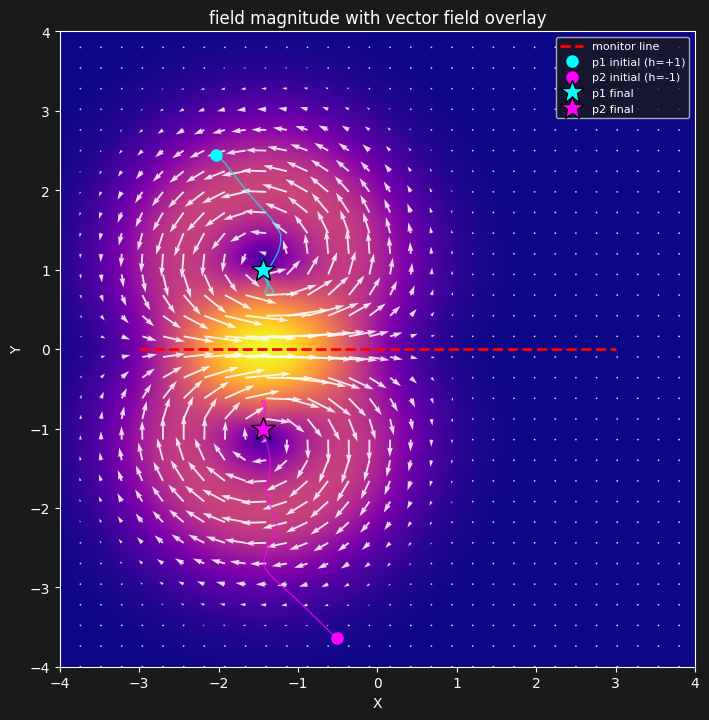

In [15]:
if show_midplane:
    fig, ax = plt.subplots(1, 1, figsize=(8.25, 8.25))
    ax.imshow(
        displayed_grid.T, cmap="plasma",
        extent=(-co_size[0]/2, co_size[0]/2, -co_size[1]/2, co_size[1]/2),
        origin="lower",
    )

    step_x = co_resolution[0] // 30
    step_y = co_resolution[1] // 30
    res2d = (co_res_new[0], co_res_new[1])
    X = coor[0].reshape(res2d)[::step_x, ::step_y]
    Y = coor[1].reshape(res2d)[::step_x, ::step_y]
    U = np.asarray(field_flat[0]).reshape(res2d)[::step_x, ::step_y]
    V = np.asarray(field_flat[1]).reshape(res2d)[::step_x, ::step_y]
    ax.quiver(X, Y, U, V, color="white", scale_units="xy", scale=3.0, width=0.003, alpha=0.85)

    ax.hlines(y=line_y, xmin=-line_extent/2, xmax=line_extent/2,
              color="red", linestyle="--", linewidth=2, label="monitor line")

    ax.plot(trajectory[:, 0], trajectory[:, 1], color="cyan", linewidth=1, alpha=0.7)
    ax.plot(trajectory[:, 2], trajectory[:, 3], color="magenta", linewidth=1, alpha=0.7)

    ax.plot(x1_init, y1_init, "o", color="cyan", markersize=8,
            label=f"p1 initial (h={handedness_1:+d})")
    ax.plot(x2_init, y2_init, "o", color="magenta", markersize=8,
            label=f"p2 initial (h={handedness_2:+d})")
    ax.plot(x1_sol, y1_sol, "*", color="cyan", markersize=18,
            markeredgecolor="black", label="p1 final")
    ax.plot(x2_sol, y2_sol, "*", color="magenta", markersize=18,
            markeredgecolor="black", label="p2 final")

    ax.set_xlim(-co_size[0]/2, co_size[0]/2)
    ax.set_ylim(-co_size[1]/2, co_size[1]/2)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(f"{displayed_label} with vector field overlay")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_aspect("equal")
    plt.show()

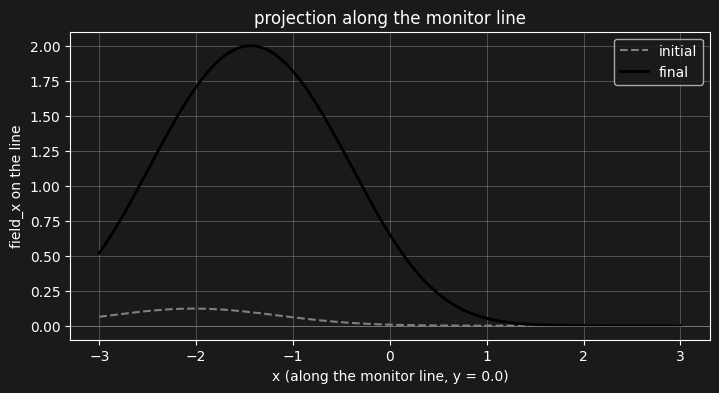

In [16]:
if show_projection:
    fig, ax = plt.subplots(1, 1, figsize=(8.25, 4))
    init_field_on_line = total_field(line_coor, init_params)[0]
    final_field_on_line = total_field(line_coor, params)[0]
    ax.plot(np.asarray(line_x), np.asarray(init_field_on_line),
            color="grey", linestyle="--", label="initial")
    ax.plot(np.asarray(line_x), np.asarray(final_field_on_line),
            color="black", linewidth=2, label="final")
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xlabel(f"x (along the monitor line, y = {line_y:.1f})")
    ax.set_ylabel("field_x on the line")
    ax.set_title("projection along the monitor line")
    ax.legend()
    ax.grid()
    plt.show()

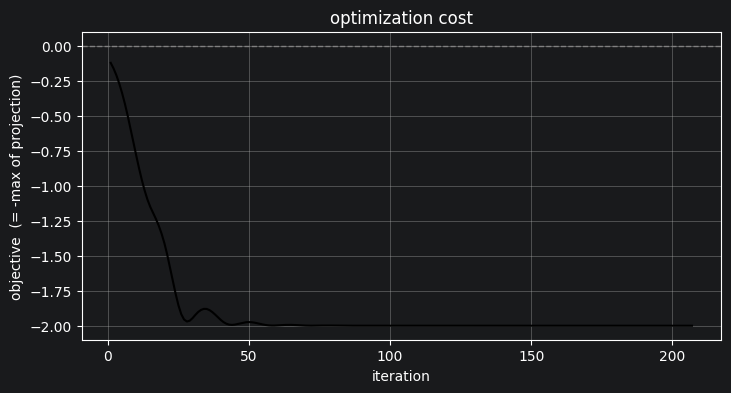

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(8.25, 4))
ax.plot(np.arange(len(cost_history)) + 1, cost_history, color="black")
ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("iteration")
ax.set_ylabel("objective  (= -max of projection)")
ax.set_title("optimization cost")
ax.grid()
plt.show()

# Things to try

* **Flip one handedness** so both are $+1$: the particles will push apart
  until their donuts no longer overlap on the monitor line.
* **Decouple `radius` and `sigma`**: they control the ring size and the
  envelope width independently. A narrow ring (small `sigma`) makes the
  optimization landscape sharper; a wider one makes convergence smoother but
  the peak lower.
* **Change the objective**: replace `-jnp.max(projection)` with
  `-jnp.sum(projection)`. You'll find the sum has no horizontal-position
  preference at all — it's constant in $x_1$ and $x_2$ (translational
  invariance along the line).
* **Move the line**: change `line_y` and watch the particles re-center to
  bracket it.